**1. Preview the Data**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Orginial Sample Data as CSV File
df = pd.read_csv("/content/sample_data/train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,06/12/2017,06/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


**2. Check dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

3. Check for Missing Values

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df[df.isnull().any(axis=1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


**4. Handle Missing Values**

In [ ]:
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont') & (df['Postal Code'].isnull()), 'Postal Code'] = 5401.0

In [ ]:
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont') ]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,5401.0,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,5401.0,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,5401.0,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,5401.0,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,5401.0,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,5401.0,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,5401.0,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,5401.0,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,5401.0,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,5401.0,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


**5. Remove Duplicate Rows**

In [ ]:
df = df.drop_duplicates()

**6. Fix Date Columns**

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

Convert to Standard YYYY-MM-DD Strings

In [ ]:
df["Order Date"] = df["Order Date"].dt.strftime("%m/%d/%Y")
df["Ship Date"] = df["Ship Date"].dt.strftime("%m/%d/%Y")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,06/12/2017,06/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


**8. Standardize Text**

In [ ]:
# Apply title case only to specific text columns
target_columns = ["Customer Name", "City", "State"]

for col in target_columns:
    df[col] = df[col].astype(str).str.title()

**9. Check Numerical Statistics**

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55217.343265,230.769059
std,2829.160653,32066.750532,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,57551.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


**10. Save Cleaned Data**

In [ ]:
df.to_csv("cleaned_superstore.csv", index=False)

# =========================
# Exploratory Data Analysis
# =========================

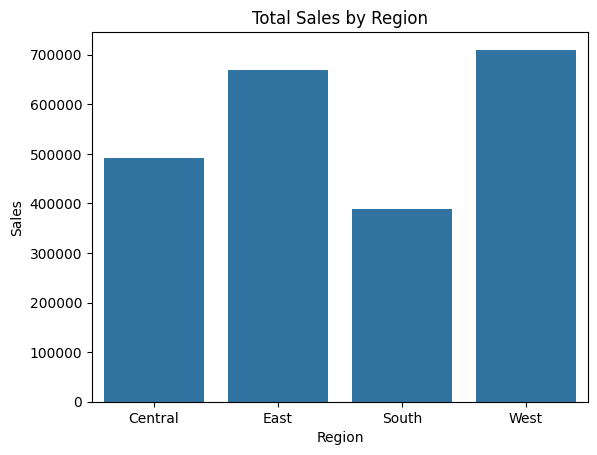

In [ ]:
# Insight:
# The West region generated the highest sales overall,
# indicating stronger customer demand in that market.

sales_by_region = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(data=sales_by_region, x="Region", y="Sales")

plt.title("Total Sales by Region")
plt.show()

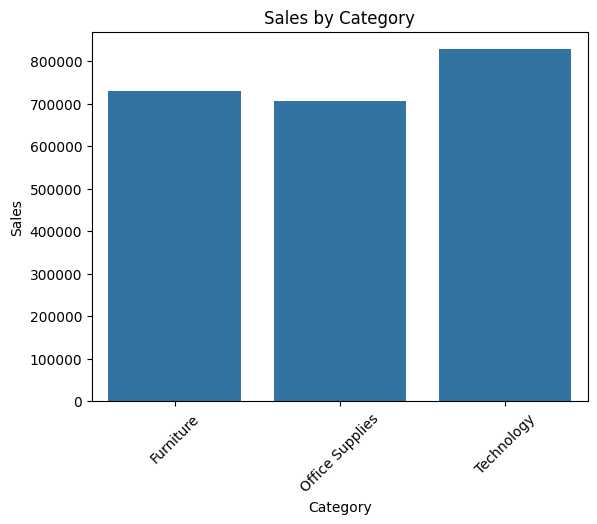

In [ ]:
# Insight:
# Technology and Furniture are the primary revenue drivers,
# while Office Supplies lags slightly behind in total sales.

sales_by_category = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(data=sales_by_category, x="Category", y="Sales")

plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

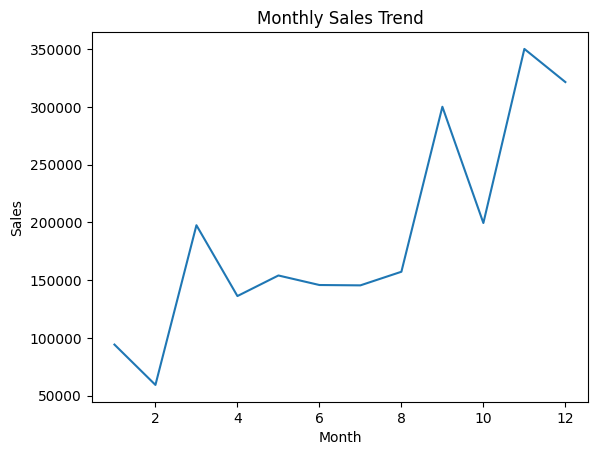

In [ ]:
# Insight:
# Sales peak significantly during the final months of the year,
# likely driven by holiday shopping and year-end corporate purchasing.

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="Month", y="Sales")

plt.title("Monthly Sales Trend")
plt.show()

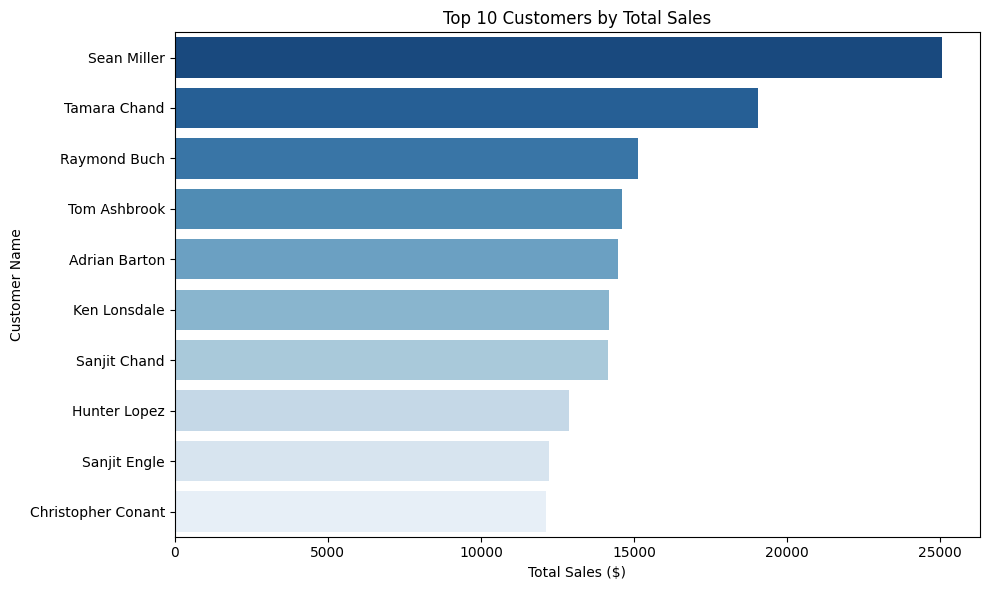

In [5]:

sales_by_customer = df.groupby("Customer Name")["Sales"].sum().reset_index()

top_10_customers = sales_by_customer.sort_values(by="Sales", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_customers, x="Sales", y="Customer Name", hue="Customer Name", palette="Blues_r", legend=False)

plt.xlabel("Total Sales ($)")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Total Sales")
plt.tight_layout() # Prevents labels from getting cut off
plt.show()


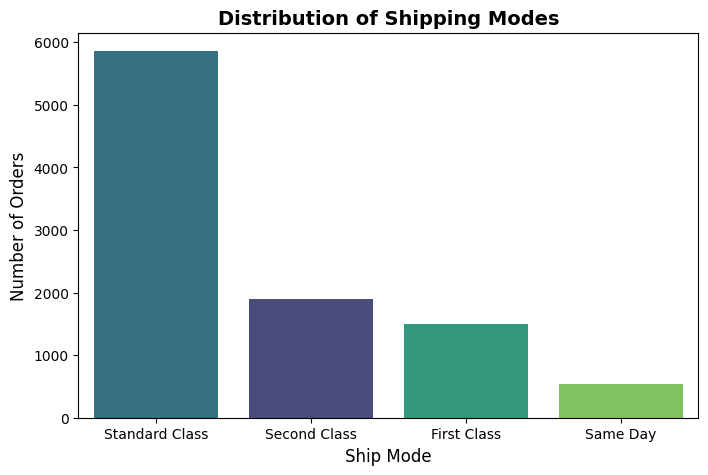

In [4]:
# Insight:
# Standard Class is overwhelmingly the most preferred shipping mode,
# indicating customers heavily prioritize lower costs over delivery speed.

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Ship Mode", order=df["Ship Mode"].value_counts().index, hue="Ship Mode", palette="viridis", legend=False)

plt.title("Distribution of Shipping Modes", fontsize=14, fontweight='bold')
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.show()


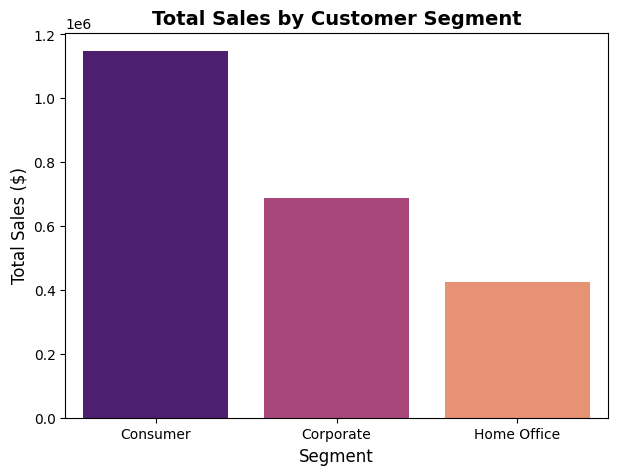

In [6]:
# Insight:
# The Consumer segment represents the largest market share,
# generating more than double the revenue of the Home Office segment.

# 1. Group by Segment and sum the Sales
sales_by_segment = df.groupby("Segment")["Sales"].sum().reset_index()

# Sort from highest sales to lowest
sales_by_segment = sales_by_segment.sort_values(by="Sales", ascending=False)

# 2. Plot the bar chart
plt.figure(figsize=(7, 5))
sns.barplot(
    data=sales_by_segment,
    x="Segment",
    y="Sales",
    hue="Segment",
    legend=False,
    palette="magma"
)

# 3. Add titles and clean up labels
plt.title("Total Sales by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.show()

This project includes an interactive Tableau dashboard built using the cleaned dataset.

View Dashboard:
[Tableu Dashboard visualization ](https://public.tableau.com/views/RetailSalesAnalysisDashboardTableau/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

# =========================
# Database Storage & SQL Analysis
# =========================



In [ ]:
import sqlite3
import pandas as pd

df = pd.read_csv("/content/cleaned_superstore.csv")

conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

9800

In [ ]:
%load_ext sql
%sql sqlite:///sales.db

In [ ]:
# Run the SQL query through Pandas using your active connection
query = """
SELECT
    SUM(Sales) AS total_sales
FROM sales;
"""
df_sales = pd.read_sql_query(query, conn)

# Display the result table
df_sales

,total_sales
0,2.261537e+06


In [ ]:
query = """
SELECT
    "Customer Name" AS unique_customer,
    Sales
FROM sales
ORDER BY Sales DESC
LIMIT 10;
"""

df_cust = pd.read_sql_query(query, conn)

# Display the result table
df_cust

,unique_customer,Sales
0,Sean Miller,22638.480
1,Tamara Chand,17499.950
2,Raymond Buch,13999.960
3,Tom Ashbrook,11199.968
4,Hunter Lopez,10499.970
5,Adrian Barton,9892.740
6,Sanjit Chand,9449.950
7,Bill Shonely,9099.930
8,Sanjit Engle,8749.950
9,Christopher Conant,8399.976


In [ ]:
query = """
SELECT
    "Ship Mode" AS Shipping,
    MAX(Sales) AS top_sales
FROM sales
GROUP BY "Ship Mode"
ORDER BY top_sales DESC;
"""

df_cust = pd.read_sql_query(query, conn)

# Display the result table
df_cust

,Shipping,top_sales
0,Standard Class,22638.48
1,First Class,13999.96
2,Second Class,8749.95
3,Same Day,7999.98
